   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


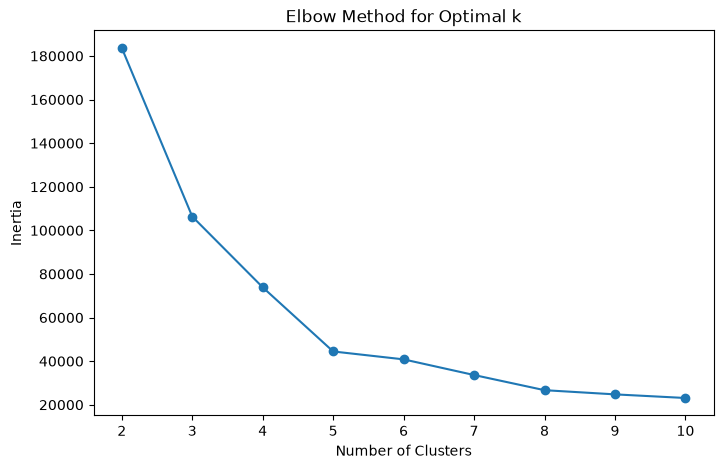

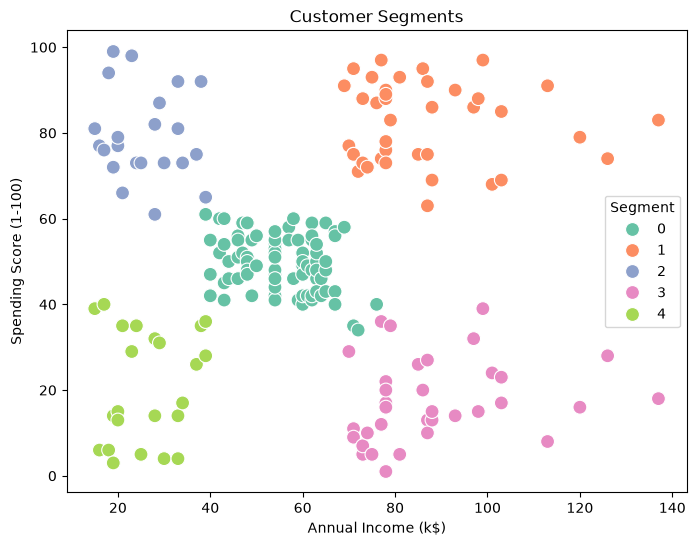

               Age  Annual Income (k$)  Spending Score (1-100)
Segment                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


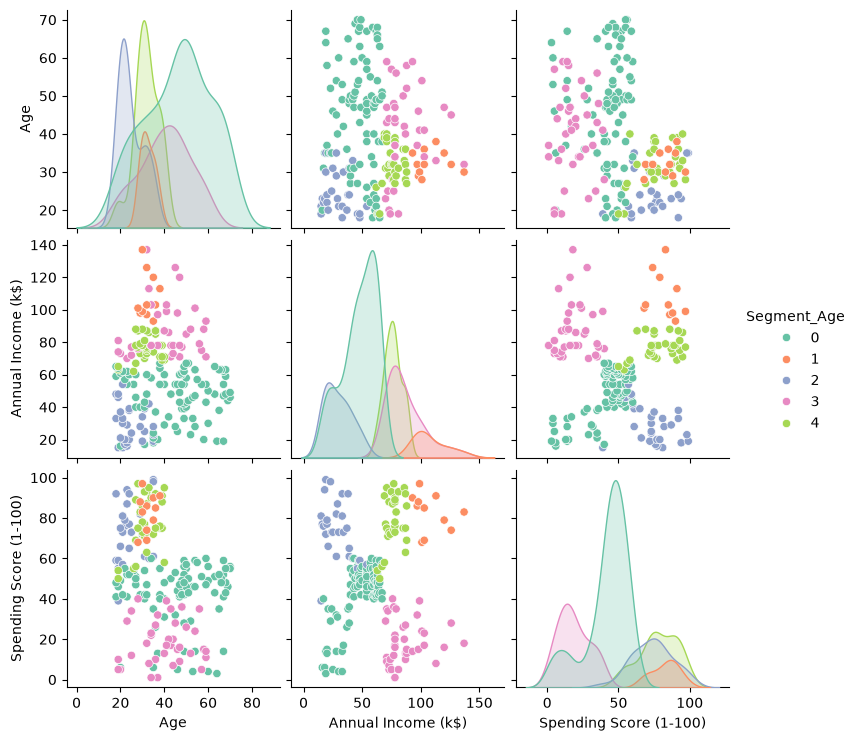

In [33]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Step 2: Load Dataset
df = pd.read_csv("Mall_Customers.csv")
print(df.head())

# Step 3: Select Features (Annual Income & Spending Score)
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Step 4: Elbow Method to find optimal clusters
inertia = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

# Step 5: Apply KMeans with chosen k (usually 5)
kmeans = KMeans(n_clusters=5, random_state=42)
df["Segment"] = kmeans.fit_predict(X)

# Step 6: Visualize Clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)",
                hue="Segment", data=df, palette="Set2", s=100)
plt.title("Customer Segments")
plt.show()

# Step 7: Analyze Segment Characteristics
segment_analysis = df.groupby("Segment")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()
print(segment_analysis)

# Step 8: Optional - Add Age into clustering for richer segmentation
X2 = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
kmeans2 = KMeans(n_clusters=5, random_state=42)
df["Segment_Age"] = kmeans2.fit_predict(X2)

# Visualize with Age included (pairplot)
sns.pairplot(df, vars=["Age", "Annual Income (k$)", "Spending Score (1-100)"], hue="Segment_Age", palette="Set2")
plt.show()
